In [38]:
import os
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from coffea.util import load
import correctionlib
from pocket_coffea.utils.configurator import Configurator

In [6]:
filename = "/work/mmarcheg/BTVNanoCommissioning/output/pocket_coffea/pt_reweighting/pt_eta_tau21_reweighting_2016_PreVFP_coarse_v06/FatJetGoodNMuon1_pt_eta_2016_PreVFP_reweighting.json"
cset = correctionlib.CorrectionSet.from_file(filename)
key = list(cset.keys())[0]
key

'FatJetGoodNMuon1_pt_eta_corr_2016_PreVFP'

In [7]:
cat = "inclusive"
pos = 0
pt = 500.0
eta = 0.0
cset[key].evaluate(cat, pos, pt, eta)

1.0524262619378464

In [12]:
PATH = "/work/mmarcheg/BTVNanoCommissioning"
os.chdir(PATH)
config = Configurator("config/pt_reweighting/ptreweighting_2017UL.py")
config

The output will be saved to output/pocket_coffea/pt_reweighting/pt_eta_tau21_reweighting_2017_coarse_v02
Saving config file to output/pocket_coffea/pt_reweighting/pt_eta_tau21_reweighting_2017_coarse_v02/config.json


In [17]:
ax_pos, ax_pt, ax_eta = config.variables["FatJetGoodNMuon1_pt_eta"].axes

In [48]:
ax_pt.bins

[450.0, 500.0, 550.0, 600.0, 700.0, 800.0, 900.0, 2500.0]

In [49]:
def centers(bins):
    return bins[:-1] + 0.5*np.ediff1d(bins)

In [50]:
pt = centers(ax_pt.bins)
eta = centers(ax_eta.bins)
pt, eta

(array([ 475.,  525.,  575.,  650.,  750.,  850., 1700.]),
 array([-3.5  , -1.875, -1.625, -1.375, -1.125, -0.875, -0.625, -0.375,
        -0.125,  0.125,  0.375,  0.625,  0.875,  1.125,  1.375,  1.625,
         1.875,  3.5  ]))

In [51]:
eta, pt = np.meshgrid(centers(ax_eta.bins), centers(ax_pt.bins))
pt = ak.flatten(pt)
eta = ak.flatten(eta)
pt, eta

(<Array [475, 475, 475, ... 1.7e+03, 1.7e+03] type='126 * float64'>,
 <Array [-3.5, -1.88, -1.62, ... 1.88, 3.5] type='126 * float64'>)

In [52]:
sf = cset[key].evaluate(cat, pos, pt, eta)
sf

array([1.11144348, 1.0376155 , 1.09231777, 1.04097639, 0.99140219,
       1.01604766, 1.02137051, 1.003795  , 1.00348167, 1.02124729,
       1.0004941 , 1.01754467, 1.03321287, 1.0082025 , 1.08632765,
       1.13631308, 1.12272274, 1.18330767, 1.12922771, 1.05163989,
       1.11115688, 1.08921474, 1.05685174, 1.01153798, 1.06792302,
       1.03011687, 1.03659584, 1.05242626, 1.03696775, 1.06178462,
       1.07672732, 1.0226632 , 1.11927606, 1.15576001, 1.13024444,
       1.22144674, 1.04954896, 1.05491614, 1.15998751, 1.10360425,
       1.08346179, 1.01853356, 1.05412221, 1.06687844, 1.04983681,
       1.07479118, 1.06049362, 1.05801405, 1.05209236, 1.09233898,
       1.11965302, 1.16727751, 1.10972651, 1.19014388, 1.03357474,
       1.15772494, 1.1281015 , 1.14885879, 1.08322976, 1.06158138,
       1.07675672, 1.07764652, 1.08197708, 1.0682587 , 1.03164145,
       1.06926545, 1.05515646, 1.09485792, 1.16475724, 1.23275177,
       1.1916967 , 1.20321194, 1.08819382, 1.10591495, 1.24512

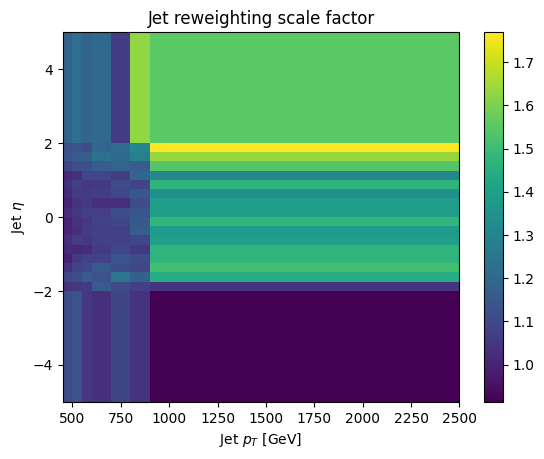

In [68]:
plt.hist2d(pt, eta, weights=sf, bins=[np.array(ax_pt.bins), np.array(ax_eta.bins)])
plt.title("Jet reweighting scale factor")
plt.xlabel("Jet $p_T$ [GeV]")
plt.ylabel("Jet $\eta$")
plt.colorbar();

In [55]:
pt.tolist()

[475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 475.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 525.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 575.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 650.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 750.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 850.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 1700.0,
 

In [56]:
eta.tolist()

[-3.5,
 -1.875,
 -1.625,
 -1.375,
 -1.125,
 -0.875,
 -0.625,
 -0.375,
 -0.125,
 0.125,
 0.375,
 0.625,
 0.875,
 1.125,
 1.375,
 1.625,
 1.875,
 3.5,
 -3.5,
 -1.875,
 -1.625,
 -1.375,
 -1.125,
 -0.875,
 -0.625,
 -0.375,
 -0.125,
 0.125,
 0.375,
 0.625,
 0.875,
 1.125,
 1.375,
 1.625,
 1.875,
 3.5,
 -3.5,
 -1.875,
 -1.625,
 -1.375,
 -1.125,
 -0.875,
 -0.625,
 -0.375,
 -0.125,
 0.125,
 0.375,
 0.625,
 0.875,
 1.125,
 1.375,
 1.625,
 1.875,
 3.5,
 -3.5,
 -1.875,
 -1.625,
 -1.375,
 -1.125,
 -0.875,
 -0.625,
 -0.375,
 -0.125,
 0.125,
 0.375,
 0.625,
 0.875,
 1.125,
 1.375,
 1.625,
 1.875,
 3.5,
 -3.5,
 -1.875,
 -1.625,
 -1.375,
 -1.125,
 -0.875,
 -0.625,
 -0.375,
 -0.125,
 0.125,
 0.375,
 0.625,
 0.875,
 1.125,
 1.375,
 1.625,
 1.875,
 3.5,
 -3.5,
 -1.875,
 -1.625,
 -1.375,
 -1.125,
 -0.875,
 -0.625,
 -0.375,
 -0.125,
 0.125,
 0.375,
 0.625,
 0.875,
 1.125,
 1.375,
 1.625,
 1.875,
 3.5,
 -3.5,
 -1.875,
 -1.625,
 -1.375,
 -1.125,
 -0.875,
 -0.625,
 -0.375,
 -0.125,
 0.125,
 0.375,
 0.625,
 0.